In [7]:
!pip install facenet_pytorch

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import PIL
import torch
import torchvision
from facenet_pytorch import MTCNN, InceptionResnetV1
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets
import zipfile
import numpy as np

In [10]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda:0


# Initializing MTCNN and Inception-ResNet V1

In [11]:
mtcnn0 = MTCNN(image_size=240, keep_all=False, min_face_size=4)
print(mtcnn0)

MTCNN(
  (pnet): PNet(
    (conv1): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=10)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(10, 16, kernel_size=(3, 3), stride=(1, 1))
    (prelu2): PReLU(num_parameters=16)
    (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (prelu3): PReLU(num_parameters=32)
    (conv4_1): Conv2d(32, 2, kernel_size=(1, 1), stride=(1, 1))
    (softmax4_1): Softmax(dim=1)
    (conv4_2): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
  )
  (rnet): RNet(
    (conv1): Conv2d(3, 28, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=28)
    (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(28, 48, kernel_size=(3, 3), stride=(1, 1))
    (prelu2): PReLU(num_parameters=48)
    (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv3): Conv2d(48, 64,

In [12]:
resnet = InceptionResnetV1(pretrained="vggface2").eval().to(device)

  0%|          | 0.00/107M [00:00<?, ?B/s]

# Data Preparation

In [13]:
source_zip = Path("/content/drive/MyDrive/sorted_faces.zip")
destination_dir = Path("sorted_faces")

# 2. Extract the file using the defined variables
with zipfile.ZipFile(source_zip, "r") as zip_ref:
    zip_ref.extractall(destination_dir)
    print(f"Successfully extracted to: {destination_dir}")

Successfully extracted to: sorted_faces


In [14]:
from pathlib import Path

# Point this to your main sorted_faces directory
data_dir = Path("/content/sorted_faces/sorted_faces")
MAX_IMAGES = 300

print("Starting folder cleanup...")

# Loop through each subfolder (e.g., barack_bukusi, edward_kirathe)
for class_dir in data_dir.iterdir():
    if class_dir.is_dir():
        # Grab all image files in the folder
        images = list(class_dir.glob("*.*"))

        if len(images) > MAX_IMAGES:
            # Separate the ones we want to keep vs. delete
            images_to_delete = images[MAX_IMAGES:]

            # Delete the excess files from the disk
            for img_path in images_to_delete:
                img_path.unlink()

            print(f"[{class_dir.name}] Kept 300. Deleted {len(images_to_delete)} excess images.")
        else:
            print(f"[{class_dir.name}] Only contains {len(images)} images. Nothing deleted.")

print("Cleanup complete! Your folders now have a maximum of 300 images each.")

Starting folder cleanup...
[edward_kirathe] Kept 300. Deleted 4493 excess images.
[barack_bukusi] Kept 300. Deleted 952 excess images.
Cleanup complete! Your folders now have a maximum of 300 images each.


In [15]:
images_folder = Path("/content/sorted_faces/sorted_faces")

print(f"Path to images: {images_folder}")

Path to images: /content/sorted_faces/sorted_faces


In [16]:
dataset = datasets.ImageFolder(images_folder)

print(dataset)

Dataset ImageFolder
    Number of datapoints: 600
    Root location: /content/sorted_faces/sorted_faces


In [17]:
for subdirectory in images_folder.iterdir():
    print(subdirectory)

/content/sorted_faces/sorted_faces/edward_kirathe
/content/sorted_faces/sorted_faces/barack_bukusi


In [18]:
dataset.class_to_idx

{'barack_bukusi': 0, 'edward_kirathe': 1}

In [19]:
idx_to_class = {i:c for c, i in dataset.class_to_idx.items()}

print(idx_to_class)

{0: 'barack_bukusi', 1: 'edward_kirathe'}


In [20]:
def collate_fn(x):
    return x[0]

In [21]:
loader = DataLoader(dataset, collate_fn=collate_fn)

print(loader.dataset)

Dataset ImageFolder
    Number of datapoints: 600
    Root location: /content/sorted_faces/sorted_faces


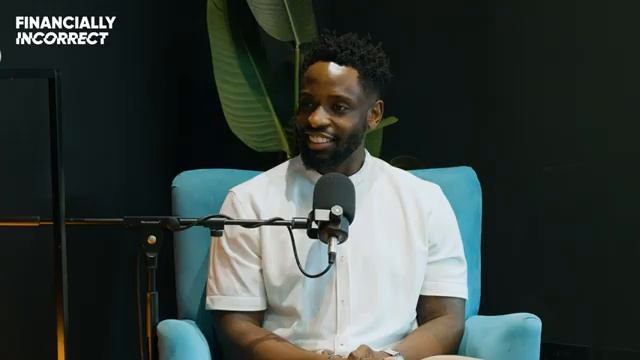

In [22]:
img, _ = iter(loader).__next__()
img

In [23]:
face, prob = mtcnn0(img, return_prob=True)

print(type(face))
print(f"Probability of detected face: {prob}")

<class 'torch.Tensor'>
Probability of detected face: 0.9998427629470825


# Running Inception-Resnet V1

In [24]:
print(face.shape)

torch.Size([3, 240, 240])


In [25]:
face_4d = face.unsqueeze(0)

print(face_4d.shape)

torch.Size([1, 3, 240, 240])


In [26]:
# Dictionary that maps name to list of their embeddings
name_to_embeddings = {name: [] for name in idx_to_class.values()}

resnet.eval()

for img, idx in loader:
    face, prob = mtcnn0(img, return_prob=True)

    if face is not None and prob >= 0.9:
        with torch.inference_mode():
            emb = resnet(face.unsqueeze(0).to(device))

        name_to_embeddings[idx_to_class[idx]].append(
            emb.squeeze(0).cpu()
        )



In [27]:
print(name_to_embeddings.keys())
print(type(name_to_embeddings["edward_kirathe"]))

dict_keys(['barack_bukusi', 'edward_kirathe'])
<class 'list'>


In [28]:
embeddings_edward = torch.stack(name_to_embeddings["edward_kirathe"])
embeddings_barack = torch.stack(name_to_embeddings["barack_bukusi"])

embeddings_edward_shape = embeddings_edward.shape
embeddings_barack_shape = embeddings_barack.shape

print(f"Shape of stack of embeddings for edward: {embeddings_edward_shape}")
print(f"Shape of stack of embeddings for barack: {embeddings_barack_shape}")

Shape of stack of embeddings for edward: torch.Size([300, 512])
Shape of stack of embeddings for barack: torch.Size([299, 512])


In [29]:
avg_embedding_edward = torch.mean(embeddings_edward, dim=0)
avg_embedding_barack = torch.mean(embeddings_barack, dim=0)

print(f"Shape of avg_embedding: {avg_embedding_edward.shape}")
print(f"Shape of avg_embedding: {avg_embedding_barack.shape}")

Shape of avg_embedding: torch.Size([512])
Shape of avg_embedding: torch.Size([512])


In [30]:
embeddings_to_save = [
    (avg_embedding_edward, "edward_kirathe"),
    (avg_embedding_barack, "barack_bukusi"),
]

torch.save(embeddings_to_save, "embeddings.pt")

In [31]:
embedding_data = torch.load("embeddings.pt")

names = [name for _, name in embedding_data]
print(f"Loaded the embedding for: {names}")

Loaded the embedding for: ['edward_kirathe', 'barack_bukusi']


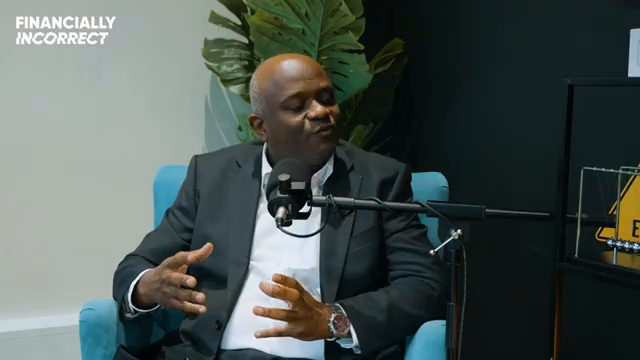

In [32]:
test_img_path = Path("/content/frame_240.jpg")

test_img = Image.open(test_img_path)
test_img

In [36]:
mtcnn_multi = MTCNN(keep_all=True, device=device)


img_cropped_list, prob_list = mtcnn_multi(test_img, return_prob=True)

print(f"Number of detected faces: {len(prob_list)}")
print(f"Probability of detected face: {prob_list[0]}")

Number of detected faces: 1
Probability of detected face: 0.9996128678321838


In [39]:
if prob_list is not None:

    with torch.no_grad():
        for i, prob in enumerate(prob_list):
            if prob > 0.90:

                face_tensor = img_cropped_list[i].unsqueeze(0).to(device)


                emb = resnet(face_tensor).detach().cpu().numpy().squeeze(0)

In [42]:
min_dist = float('inf')
closest_match = None

for known_emb, name in embedding_data:
    # If the known embedding is still a PyTorch Tensor, convert it to a NumPy array
    if torch.is_tensor(known_emb):
        # We use .cpu().detach().numpy() just in case it's still on the GPU or has gradients
        known_emb = known_emb.cpu().detach().numpy()

    # Ensure both are exactly the same shape (e.g., flattened to 1D)
    known_emb = np.squeeze(known_emb)
    emb_flat = np.squeeze(emb)

    # Now both are NumPy arrays, so the subtraction works perfectly
    dist = np.linalg.norm(emb_flat - known_emb)

    if dist < min_dist:
        min_dist = dist
        closest_match = name

print(f"Closest match: {closest_match}")
print(f"Calculated distance: {min_dist :.2f}")

Closest match: edward_kirathe
Calculated distance: 0.78


In [44]:
boxes, _ = mtcnn_multi.detect(test_img)
print(f"Shape of boxes tensor: {boxes.shape}")

Shape of boxes tensor: (1, 4)


In [45]:
threshold = 0.8

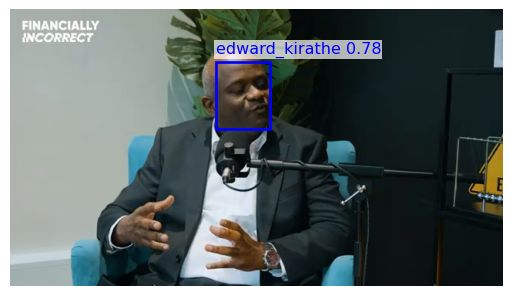

In [48]:
width, height = test_img.size
dpi = 96
fig = plt.figure(figsize=(width / dpi, height / dpi), dpi=dpi)
axis = fig.subplots()
axis.imshow(test_img)



# Ensure cropped face tensors and bounding boxes are aligned
if img_cropped_list is not None and len(boxes) > 0:
    for i, box in enumerate(boxes):

        # 1. Extract embedding for the current face
        with torch.no_grad():
            face_tensor = img_cropped_list[i].unsqueeze(0).to(device)
            emb = resnet(face_tensor).detach().cpu().numpy().squeeze(0)

        # 2. Calculate distance to all known embeddings for THIS face
        distances = {}
        for known_emb, name in embedding_data:
            if torch.is_tensor(known_emb):
                known_emb = known_emb.cpu().detach().numpy()

            known_emb = np.squeeze(known_emb)
            dist = np.linalg.norm(emb - known_emb)

            # Keep the minimum distance for each person name
            if name not in distances or dist < distances[name]:
                distances[name] = dist

        # 3. Guard against an empty distances dictionary
        if not distances:
            print("Warning: embedding_data is empty or distance calculation failed.")
            continue

        # 4. Find the closest match
        closest, min_dist = min(distances.items(), key=lambda x: x[1])

        # 5. Evaluate threshold and assign colors
        if min_dist < threshold:
            name_label = closest
            color = "blue"
        else:
            name_label = "Unrecognized"
            color = "red"

        # 6. Draw bounding box and text label
        rect = plt.Rectangle(
            (box[0], box[1]), box[2] - box[0], box[3] - box[1],
            fill=False, color=color, linewidth=2
        )
        axis.add_patch(rect)

        plt.text(
            box[0],
            box[1] - 5,
            f"{name_label} {min_dist:.2f}",
            fontsize=12,
            color=color,
            ha="left",
            va="bottom",
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
        )

plt.axis("off")
plt.show()

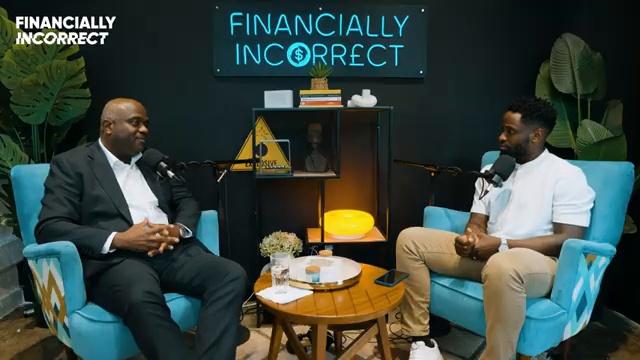

In [54]:
img_multiple_people_path = Path("/content/frame_20.jpg")
img_multiple_people = Image.open(img_multiple_people_path).convert("RGB")

img_multiple_people

In [58]:
def recognize_faces(img_path, embedding_data, mtcnn, resnet, threshold=1.0):
    # 1. FIX: Force RGB conversion to prevent 1-channel Grayscale errors
    image = Image.open(img_path).convert('RGB')

    # Generating the bounding boxes, faces tensors, and probabilities
    boxes, probs = mtcnn.detect(image)
    cropped_images = mtcnn(image)

    # Exit if no faces are found
    if boxes is None or cropped_images is None:
        print("No faces detected in the image.")
        return

    # This sets the image size and draws the original image
    width, height = image.size
    dpi = 96
    fig = plt.figure(figsize=(width / dpi, height / dpi), dpi=dpi)
    axis = fig.subplots()
    axis.imshow(image)
    plt.axis("off")

    # Iterating over each face and comparing it against the pre-calculated embeddings
    for box, prob, face in zip(boxes, probs, cropped_images):
        if prob < 0.90:
            continue

        # 2. FIX: Prevent memory leaks and move the face tensor to the GPU
        with torch.no_grad():
            face_tensor = face.unsqueeze(0).to(device)
            # Extract, detach, and convert to 1D NumPy array
            emb = resnet(face_tensor).detach().cpu().numpy().squeeze()

        # 3. FIX: Track absolute minimum distance (solves the dictionary overwrite bug)
        min_dist = float('inf')
        closest_match = None

        for known_emb, name in embedding_data:
            # Ensure known_emb is a NumPy array for math operations
            if torch.is_tensor(known_emb):
                known_emb = known_emb.cpu().detach().numpy()
            known_emb = np.squeeze(known_emb)

            # Calculate Euclidean distance using NumPy
            dist = np.linalg.norm(emb - known_emb)

            if dist < min_dist:
                min_dist = dist
                closest_match = name

        # Drawing the box with recognition results
        name = closest_match if min_dist < threshold else "Unrecognized"
        color = "red" if name == "Unrecognized" else "blue"

        # Draw bounding boxes for all detected faces
        rect = plt.Rectangle(
            (box[0], box[1]),
            box[2] - box[0],
            box[3] - box[1],
            fill=False,
            color=color,
            linewidth=2
        )
        axis.add_patch(rect)

        label = f"{name} {min_dist:.2f}"

        # Added a background box to the text so it's readable on dark backgrounds
        axis.text(
            box[0],
            box[1] - 5,
            label,
            fontsize=10,
            color=color,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
        )

    plt.axis("off")
    plt.show()

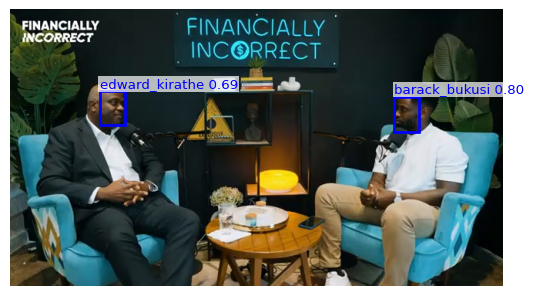

In [59]:
recognize_faces(img_multiple_people_path, embedding_data, mtcnn_multi, resnet)